## Customer Churn Prediction



### Project Overview
- This project aims to predict whether a customer is likely to churn (leave the service) based on customer demographics, account information, and service usage. By identifying customers at risk of churning, businesses can take proactive actions to improve customer retention and reduce revenue loss.

- The project follows a complete Machine Learning pipeline, including data exploration, preprocessing, model development, evaluation, explainability, and deployment.

#### Life cycle of Machine learning Project

- Understanding the Problem
- Data Collection
- Import Libraries
- Load Dataset
- Data Understanding
- Data Quality Checks
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Model Explainability (SHAP)
- Save the Best Model
- Streamlit Deployment

### 1) Problem statement
- Customer churn is one of the biggest challenges faced by subscription-based businesses such as telecommunications, banking, insurance, and SaaS companies. Losing existing customers increases customer acquisition costs and negatively impacts business revenue.
- The ability to identify customers who are likely to churn enables companies to take preventive actions, such as offering personalized promotions, improving customer support, or recommending more suitable service plans.

### 1.1 Project Objective
- The objective of this project is to build a machine learning classification model that predicts whether a customer will churn based on demographic information, account details, and subscribed services.
- The final model should help businesses identify high-risk customers and support data-driven retention strategies.

### 2) Data Collection
- Dataset Source - (https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download)

- Dataset Name: IBM Telco Customer Churn
- Records: 7,043 Customers
- Features: 21 Features + 1 Target Variable (Churn)

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [41]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

### 2.2 Load Dataset

In [42]:
df = pd.read_csv("C:\Churn-Prediction\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

### 2.3 Show Top 5 Records

In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.1 Dataset Shape

In [44]:
df.shape

(7043, 21)

The dataset contains 7,043 customer records and 21 columns (20 features + 1 target variable).

### 3.2 Dataset Information

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3.3 Statistical Summary

In [46]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The average customer has been subscribed for about 32 months, with tenure ranging from 0 (new customers) to 72 months (6 years). Average monthly charges are $64.76, ranging from $18.25 to $118.75, indicating a wide variety of service plans.

###  3.4 Check Data Types

In [47]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

###  3.5 Check Missing Values

In [48]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No missing values detected at this initial check. Note: TotalCharges is still stored as text at this stage, so its 11 hidden missing values (blank strings) will only be revealed after converting it to numeric later.

### 3.6 Check Duplicates

In [49]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found in the dataset — each of the 7,043 records represents a unique customer.

### 3.7 Check Various Categories Present in the Different Categorical Columns

Displaying the unique categories of each categorical feature helps identify inconsistencies and understand the available values.

In [50]:
categorical_columns = df.select_dtypes(include="object").columns

summary = pd.DataFrame({
    "Column": categorical_columns,
    "Number of Unique Values": [df[col].nunique() for col in categorical_columns],
    "Unique Values": [", ".join(map(str, df[col].unique())) for col in categorical_columns]
})

summary

,Column,Number of Unique Values,Unique Values
0,customerID,7043,"7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW..."
1,gender,2,"Female, Male"
2,Partner,2,"Yes, No"
3,Dependents,2,"No, Yes"
4,PhoneService,2,"No, Yes"
5,MultipleLines,3,"No phone service, No, Yes"
6,InternetService,3,"DSL, Fiber optic, No"
7,OnlineSecurity,3,"No, Yes, No internet service"
8,OnlineBackup,3,"Yes, No, No internet service"
9,DeviceProtection,3,"No, Yes, No internet service"


In [51]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


### 4. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset visually to identify patterns, trends, and relationships between features and the target variable.

The following analysis will be performed:

- Univariate Analysis
- Bivariate Analysis
- Correlation Analysis
- Business Insights

#### 4.1 Univariate Analysis

In this step, we analyze each feature individually to understand its distribution.

### 4.1.1 Target Variable Distribution

Checking the distribution of the target variable helps identify whether the dataset is balanced or imbalanced.

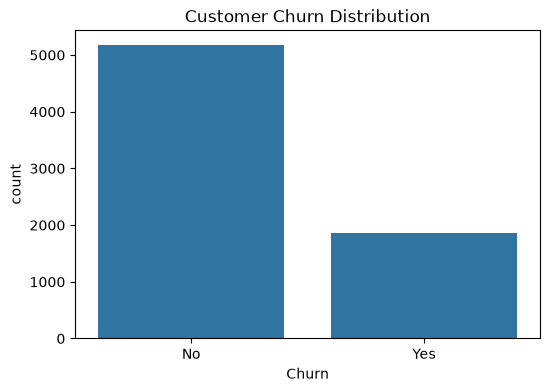

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [53]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### 4.1.2 Numerical Features Distribution

Visualizing numerical features helps understand their distribution and detect potential outliers.

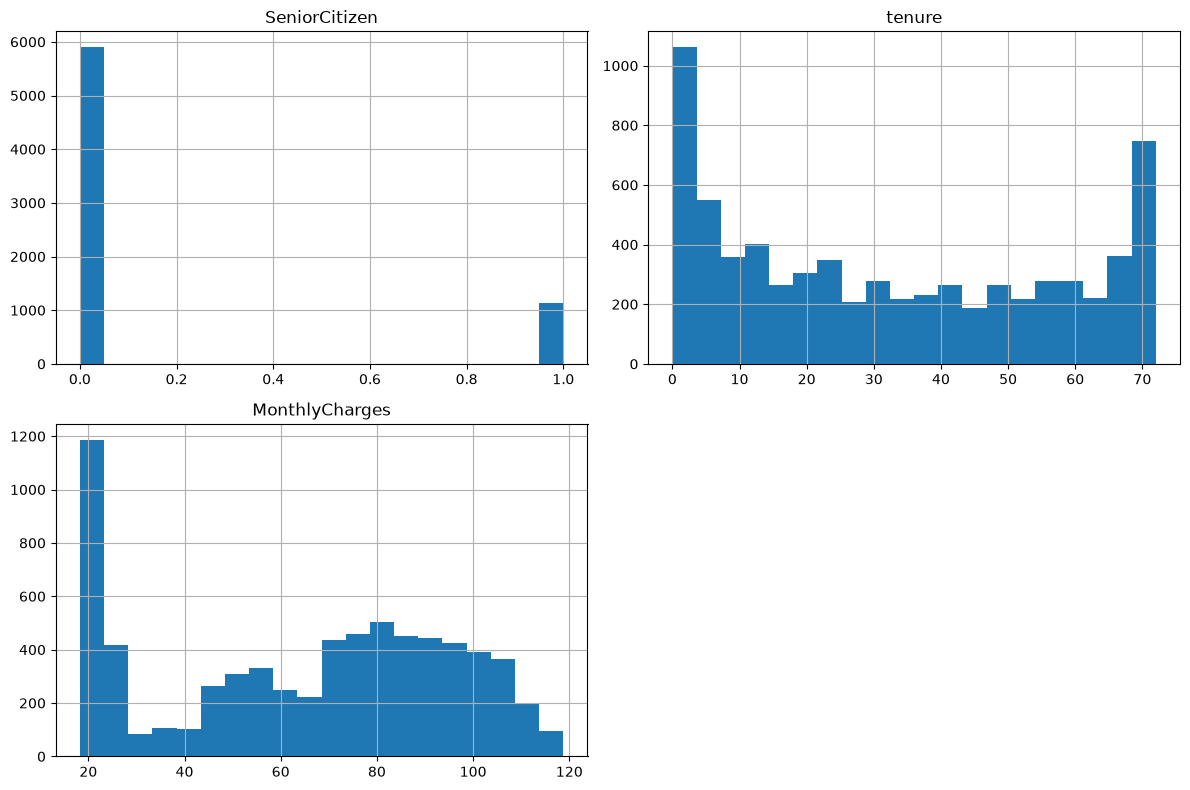

In [54]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

### 4.2 Bivariate Analysis

In this step, we analyze the relationship between each feature and the target variable.

### Numerical Features vs Churn

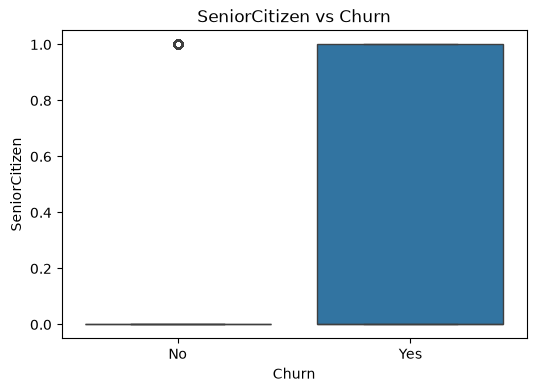

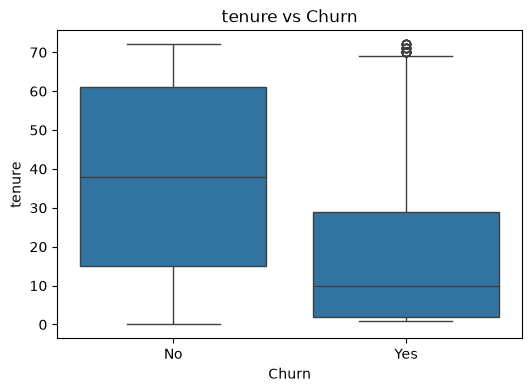

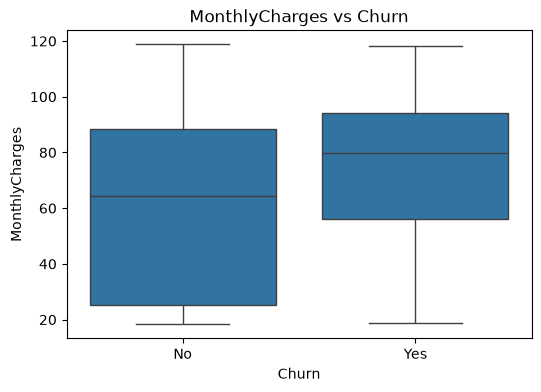

In [55]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

## 4.3 Correlation Analysis

Correlation analysis helps identify relationships between numerical features.

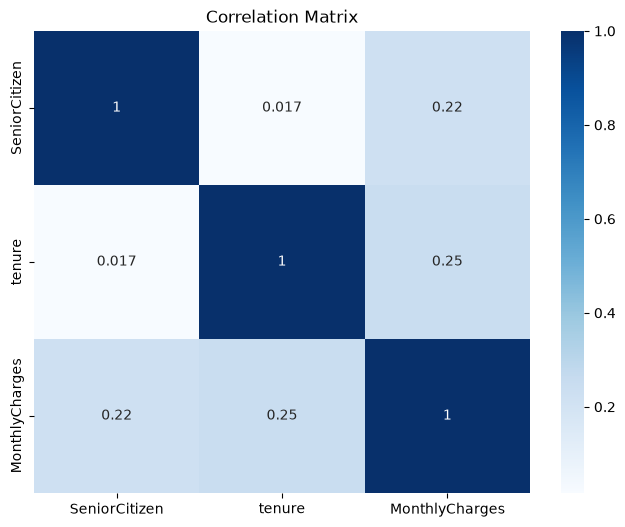

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

###  5. Data Preprocessing

In this section, we will prepare the dataset for machine learning by cleaning and transforming the data into a suitable format.

The following steps will be performed:

- Remove unnecessary features
- Convert data types
- Handle missing values
- Encode the target variable
- Encode categorical features
- Split features and target
- Split the dataset into training and testing sets
- Feature scaling

## 5.1 Remove Unnecessary Features


In [57]:
# Remove customerID column
df.drop(columns="customerID", inplace=True)

## 5.2 Convert Data Types

Convert the target variable into numerical values to make it suitable for machine learning models.

In [58]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

## 5.3 Handle Missing Values

In [59]:
# Check missing values
df["TotalCharges"].isnull().sum()

np.int64(11)

In [60]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [61]:
# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

The 11 missing values in TotalCharges  all belong to new customers ( tenure = 0), meaning they haven't accumulated a total billing amount yet — this is not a random missing value or a data error. Therefore, it was replaced with the median as a reasonable value representing a customer with no accumulated usage.

In [62]:
# Verify missing values
df["TotalCharges"].isnull().sum()

np.int64(0)

## 5.4 Encode Target Variable


In [63]:
# Encode target variable
df["Churn"] = df["Churn"].replace({"No": 0, "Yes": 1}).astype(int)

## 5.5 Encode Categorical Features

- Select categorical columns
- Apply One-Hot Encoding

In [64]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [65]:
df.to_csv("../cleaned_churn_data.csv", index=False)

In [66]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

## 5.6 Split Features and Target


In [67]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## 5.7 Split the Dataset
Split the dataset into training and testing sets

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5.8 Feature Scaling


In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

###  6. Model Building

In this section, we train multiple machine learning models and compare their performance to select the best model for customer churn prediction.

The following steps will be performed:

- Import machine learning models
- Train multiple models
- Evaluate model performance
- Compare model results
- Select the best model

### 6.1 Import Machine Learning Models

Import the machine learning models and evaluation metrics required for training and performance comparison.

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

### 6.2 Initialize the Models

Create a dictionary containing all the machine learning models that will be evaluated.

In [71]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0, auto_class_weights="Balanced"),
}

### 6.3 Train and Evaluate Models

Train each model and evaluate its performance using multiple evaluation metrics.

In [72]:
results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

### 6.4 Compare Model Performance

Display the evaluation results for all trained models.

In [73]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.738822,0.505172,0.783422,0.614256,0.841719
1,CatBoost,0.760823,0.534451,0.767380,0.630077,0.840098
2,XGBoost,0.759404,0.536082,0.695187,0.605355,0.831568
3,Random Forest,0.775018,0.567376,0.641711,0.602258,0.825455
4,Decision Tree,0.737402,0.505495,0.491979,0.498645,0.659508


In [74]:
import joblib

joblib.dump(X_train, "../models/X_train.pkl")
joblib.dump(X_test, "../models/X_test.pkl")
joblib.dump(y_train, "../models/y_train.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

['../models/y_test.pkl']

In [75]:
joblib.dump(X_train.columns.tolist(), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [76]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

### 6.5 Visual Comparison of Models

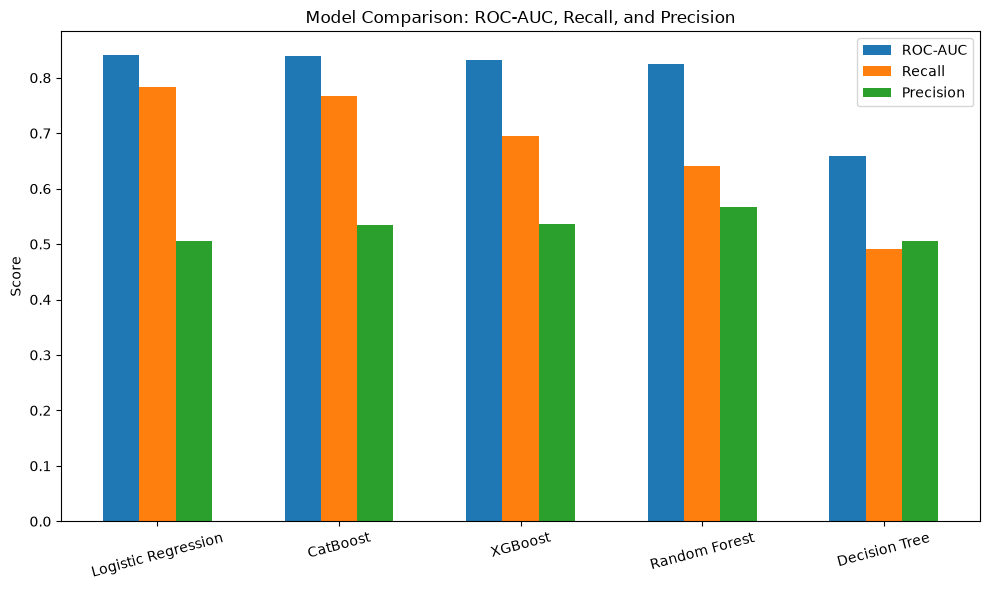

In [78]:
results_sorted = results_df.sort_values(by="ROC-AUC", ascending=False)

plt.figure(figsize=(10, 6))
x = np.arange(len(results_sorted))
width = 0.2

plt.bar(x - width, results_sorted["ROC-AUC"], width, label="ROC-AUC")
plt.bar(x, results_sorted["Recall"], width, label="Recall")
plt.bar(x + width, results_sorted["Precision"], width, label="Precision")

plt.xticks(x, results_sorted["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Comparison: ROC-AUC, Recall, and Precision")
plt.legend()
plt.tight_layout()
plt.show()